In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Phase 3: Model Training and Evaluation
# Objective: Train Machine Learning models to predict customer churn

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import roc_auc_score, roc_curve
import seaborn as sns
import matplotlib.pyplot as plt

print("Libraries for Stage 3 loaded successfully.")

# Loading the final processed data from Stage 2
file_path = "/content/drive/MyDrive/Customer Churn Prediction/data/clean/processed_churn_data.csv"
df = pd.read_csv(file_path)

print(f"Dataset ready for modeling: {df.shape}")
df.head()

Libraries for Stage 3 loaded successfully.
Dataset ready for modeling: (7032, 31)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,0,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,0,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,0,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False
4,1,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False


# **Step 3: Train-Test Split**

In [3]:
# 1. Defining Features (X) and Target (y)
X = df.drop('Churn', axis=1)  # All columns except Churn
y = df['Churn']               # Only the Churn column

# 2. Splitting the data: 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

Training set size: (5625, 30)
Testing set size: (1407, 30)


In [4]:
# 1. Initialize the Random Forest Model
# n_estimators=100 means we are using 100 decision trees
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Train the model using our Training Data
rf_model.fit(X_train, y_train)

# 3. Make predictions on the Test Data
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Training Complete!")

Random Forest Training Complete!


In [5]:
# Evaluation Metrics
print("--- Random Forest Performance ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_rf):.2%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

--- Random Forest Performance ---
Accuracy Score: 78.75%

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.63      0.48      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407



<Figure size 800x600 with 0 Axes>

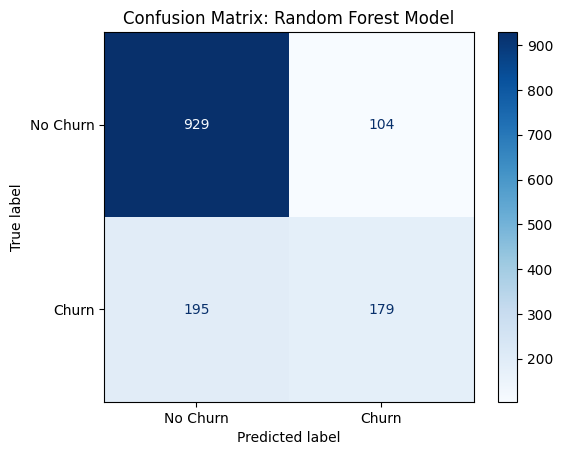

In [6]:
# Importing confusion matrix display tool
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Generate the Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)

# 2. Plotting the Matrix
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix: Random Forest Model')
plt.show()

In [7]:
# 1. Initialize the Decision Tree Model
# max_depth=10 to prevent overfitting
dt_model = DecisionTreeClassifier(max_depth=10, random_state=42)

# 2. Train the model using our Training Data
dt_model.fit(X_train, y_train)

# 3. Make predictions on the Test Data
y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Training Complete!")

Decision Tree Training Complete!


In [8]:
# Evaluation Metrics
print("--- Decision Tree Performance ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_dt):.2%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

--- Decision Tree Performance ---
Accuracy Score: 74.27%

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.82      0.82      1033
           1       0.52      0.53      0.52       374

    accuracy                           0.74      1407
   macro avg       0.67      0.67      0.67      1407
weighted avg       0.74      0.74      0.74      1407



<Figure size 800x600 with 0 Axes>

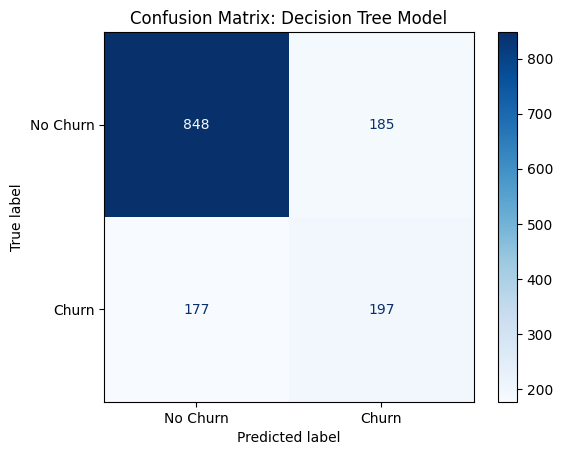

In [9]:
# Importing confusion matrix display tool
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Generate the Confusion Matrix
cm = confusion_matrix(y_test, y_pred_dt)

# 2. Plotting the Matrix
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix: Decision Tree Model')
plt.show()

In [10]:
# Model Comparison: Decision Tree vs Random Forest
dt_report = classification_report(y_test, y_pred_dt, output_dict=True)
rf_report = classification_report(y_test, y_pred_rf, output_dict=True)

# Churn class probabilities for ROC-AUC
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

comparison = pd.DataFrame({
    "Model":        ["Decision Tree", "Random Forest"],
    "Accuracy":     [
        round(accuracy_score(y_test, y_pred_dt), 4),
        round(accuracy_score(y_test, y_pred_rf), 4),
    ],
    "ROC-AUC":      [
        round(roc_auc_score(y_test, y_prob_dt), 4),
        round(roc_auc_score(y_test, y_prob_rf), 4),
    ],
    "Churn Recall": [
        round(dt_report["1"]["recall"], 4),
        round(rf_report["1"]["recall"], 4),
    ],
    "Churn F1":     [
        round(dt_report["1"]["f1-score"], 4),
        round(rf_report["1"]["f1-score"], 4),
    ],
})

print(comparison.to_string(index=False))

        Model  Accuracy  ROC-AUC  Churn Recall  Churn F1
Decision Tree    0.7427   0.7363        0.5267    0.5212
Random Forest    0.7875   0.8184        0.4786    0.5449


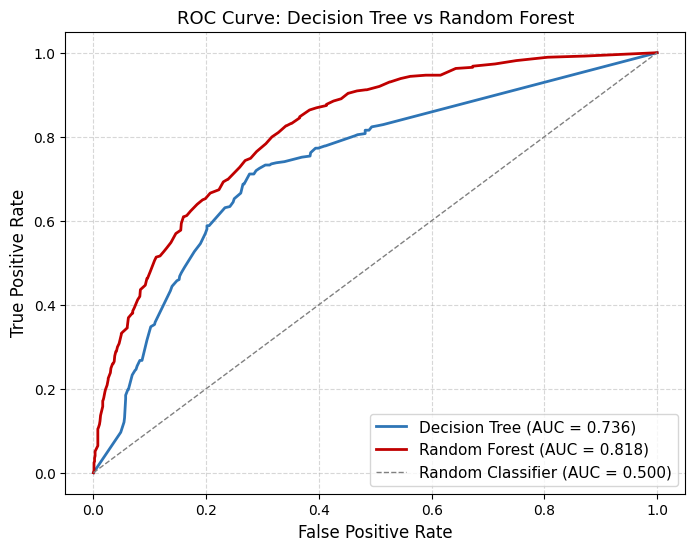

In [11]:
# ROC Curve: Decision Tree vs Random Forest
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

auc_dt = roc_auc_score(y_test, y_prob_dt)
auc_rf = roc_auc_score(y_test, y_prob_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {auc_dt:.3f})", color="#2E75B6", linewidth=2)
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})", color="#C00000", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--", color="grey", linewidth=1, label="Random Classifier (AUC = 0.500)")

plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve: Decision Tree vs Random Forest", fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [12]:
import joblib

# Save the trained Random Forest model to your Drive
model_save_path = "/content/drive/MyDrive/Customer Churn Prediction/models/churn_model_rf.pkl"
joblib.dump(rf_model, model_save_path)
print(f"Random Forest model saved at: {model_save_path}")

# Save the trained Decision Tree model to your Drive
dt_save_path = "/content/drive/MyDrive/Customer Churn Prediction/models/churn_model_dt.pkl"
joblib.dump(dt_model, dt_save_path)
print(f"Decision Tree model saved at: {dt_save_path}")

print("\nModels are ready for Gen AI Phase")

Random Forest model saved at: /content/drive/MyDrive/Customer Churn Prediction/models/churn_model_rf.pkl
Decision Tree model saved at: /content/drive/MyDrive/Customer Churn Prediction/models/churn_model_dt.pkl

Models are ready for Gen AI Phase
